#### **Student's Admission using ANN**

1.  The main objective of the problem statement whether the student will get the admission based on GRE, TOEFEL and CGPA details.

#### **Steps required in this process:-**

1.  Import all the necessary libraries

2.  Load the dataset

3.  Perform the data exploration

4.  Do data preprocessing

5.  Divide the dataset into independent and dependent variables

6.  Divide the independent and dependent variables into training and testing data

7.  Perform the Feature Scaling on the input data

8.  Build the simple neural network

9.  Compile the model

10. Train the model

11. Evaluate the model

12. Visualize the training history

13. Make the Predictions

14. Check whether the student will get the admission or not

#### **Step 1: Import all the necessary libraries**

In [392]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn           as sns

from   sklearn.model_selection import train_test_split
from   sklearn.preprocessing   import StandardScaler

from   tensorflow.keras.models import Sequential
from   tensorflow.keras.layers import Dense

#### **OBSERVATIONS:**

1.  Sequential ------->  Creates a sequential model

2.  Dense      ------->  Creates a dense layer in the sequential model.

#### **Step 2: Load the dataset**

In [393]:
#### Load the dataset
df = pd.read_csv('/content/Admission_Predict.csv')

In [394]:
df

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


#### **OBSERVATIONS:**

1.  The dataset explains about the details of the students that tells whether the student will have the chance to get admission in an univerisity based on GRE Score, TOEFEL Score.

#### **Step 3: Perform the data exploration**

In [395]:
#### Get the length of the dataset
print("Length of the dataset is:",len(df))

Length of the dataset is: 400


In [396]:
#### Get the shape of the dataset
print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (400, 9)


In [397]:
#### Get the columns used in the dataset
print("Columns used in the dataset is:", df.columns)

Columns used in the dataset is: Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')


In [398]:
#### Get the information about the columns used in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [399]:
#### get the descriptive summary statistics about the columns used in the dataset
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


####  **OBSERVATIONS:**

1.  The above table explains about the statistical summary information for each numerical column used in the dataset.

#### **Step 4: Do data preprocessing**

In [400]:
#### To check for the null records in the dataset
df.isnull().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


#### **OBSERVATIONS:**

1.  There are no NULL records for any of the column in the dataset.

In [401]:
#### To check for the duplicate records in the dataset
df[df.duplicated()]

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit


In [402]:
type(df)

pandas.core.frame.DataFrame

#### **OBSERVATIONS:**

1.  There are no duplicate records in the dataset.

In [403]:
#### Strip all the names of the columns
df.columns = df.columns.str.strip()

In [404]:
#### Divide the dataset into independent and dependent variables
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR', 'CGPA', 'Research', 'Chance of Admit'],
      dtype='object')

#### **Step 5: Divide the dataset into independent and dependent variables**

In [405]:
#### Independent features
X = df.drop(columns=['Chance of Admit'],axis=1)

In [406]:
X

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,1,337,118,4,4.5,4.5,9.65,1
1,2,324,107,4,4.0,4.5,8.87,1
2,3,316,104,3,3.0,3.5,8.00,1
3,4,322,110,3,3.5,2.5,8.67,1
4,5,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1
396,397,325,107,3,3.0,3.5,9.11,1
397,398,330,116,4,5.0,4.5,9.45,1
398,399,312,103,3,3.5,4.0,8.78,0


#### **OBSERVATIONS:**

1.  The above dataset contains all the inputs from the Serial No ....... Research

In [407]:
#### Dependent features
Y = df['Chance of Admit']

In [408]:
Y = (Y > 0.5).astype(int)

In [409]:
Y

,Chance of Admit
0,1
1,1
2,1
3,1
4,1
...,...
395,1
396,1
397,1
398,1


#### **OBSERVATIONS:**

1.  The dependent feature has the feature 'Chance of Admit' that determines whether the student will have the chance to get admission into the university or not.

#### **Step 6: Divide the independent and dependent variables into training and testing data**

In [410]:
#### independent variables
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [411]:
X_train

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
141,142,332,118,2,4.5,3.5,9.36,1
232,233,312,107,2,2.5,3.5,8.27,0
397,398,330,116,4,5.0,4.5,9.45,1
165,166,322,110,5,4.5,4.0,8.97,0
113,114,320,110,2,4.0,3.5,8.56,0
...,...,...,...,...,...,...,...,...
91,92,299,97,3,5.0,3.5,7.66,0
296,297,310,107,3,3.5,3.5,8.67,0
217,218,321,109,4,4.0,4.0,9.13,1
0,1,337,118,4,4.5,4.5,9.65,1


In [412]:
X_test

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
56,57,316,102,3,2.0,3.0,7.40,0
275,276,322,110,3,3.5,3.0,8.96,1
347,348,299,94,1,1.0,1.0,7.34,0
31,32,327,103,3,4.0,4.0,8.30,1
294,295,316,101,2,2.5,2.0,8.32,1
...,...,...,...,...,...,...,...,...
151,152,332,116,5,5.0,5.0,9.28,1
65,66,325,112,4,3.5,3.5,8.92,0
96,97,306,100,2,3.0,3.0,8.00,0
57,58,298,99,2,4.0,2.0,7.60,0


In [413]:
print("Shape of the input training data is:", X_train.shape)
print("Shape pf the input testing  data is:", X_test.shape)

Shape of the input training data is: (320, 8)
Shape pf the input testing  data is: (80, 8)


In [414]:
Y_train

,Chance of Admit
141,1
232,1
397,1
165,1
113,1
...,...
91,0
296,1
217,1
0,1


In [415]:
Y_test

,Chance of Admit
56,1
275,1
347,0
31,1
294,1
...,...
151,1
65,1
96,0
57,0


In [416]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape pf the output testing  data is:", Y_test.shape)

Shape of the output training data is: (320,)
Shape pf the output testing  data is: (80,)


#### **Step 7: Perform the Feature Scaling on the input data**

In [417]:
from sklearn.preprocessing import StandardScaler

#### create an object for Standard Scaler
sc = StandardScaler()

#### using the object of Standard Scaler, transform the inputs
X_train_scaled = sc.fit_transform(X_train)

X_test_scaled  = sc.transform(X_test)

In [418]:
X_train_scaled

array([[-0.49974751,  1.2992328 ,  1.72679211, ...,  0.02149944,
         1.24765345,  0.8819171 ],
       [ 0.29188865, -0.46318558, -0.10457524, ...,  0.02149944,
        -0.59946677, -1.13389342],
       [ 1.72727289,  1.12299096,  1.39381623, ...,  1.16813618,
         1.40016796,  0.8819171 ],
       ...,
       [ 0.16139917,  0.32990269,  0.22840064, ...,  0.59481781,
         0.85789413,  0.8819171 ],
       [-1.72634859,  1.73983739,  1.72679211, ...,  1.16813618,
         1.7390891 ,  0.8819171 ],
       [-0.48234891,  2.00420015,  2.05976799, ...,  0.59481781,
         2.19663264,  0.8819171 ]])

In [419]:
X_test_scaled

array([[-1.23918788, -0.1107019 , -0.93701494, -0.12567332, -1.43528838,
        -0.55181893, -2.07377372, -1.13389342],
       [ 0.66595848,  0.41802361,  0.39488858, -0.12567332,  0.078862  ,
        -0.55181893,  0.56981117,  0.8819171 ],
       [ 1.29230797, -1.60875753, -2.26891847, -1.91302724, -2.44472197,
        -2.84509242, -2.17545006, -1.13389342],
       [-1.45667034,  0.8586282 , -0.770527  , -0.12567332,  0.58357879,
         0.59481781, -0.54862859,  0.8819171 ],
       [ 0.83124515, -0.1107019 , -1.10350288, -1.01935028, -0.93057159,
        -1.69845568, -0.51473648,  0.8819171 ],
       [-1.41317385, -1.60875753, -0.27106318, -1.01935028,  0.58357879,
         0.59481781, -0.37916802, -1.13389342],
       [-1.59585911, -0.28694374, -0.43755112, -0.12567332,  0.078862  ,
        -1.1251373 , -0.54862859, -1.13389342],
       [ 0.27449005, -0.37506466, -0.60403906, -0.12567332,  0.58357879,
         1.16813618,  0.0444834 , -1.13389342],
       [ 1.118322  , -1.9612412 

#### **OBSERVATIONS:**

1.  All the input features have been scaled in the same scale range between 0 to 1.

In [420]:
X_train.shape[1]

8

#### **Step 8: Build the simple neural network**

In [421]:
from tensorflow.keras.layers import Dropout

In [422]:
model = Sequential([
    #### create the first dense layer
    Dense(128,activation='relu',input_shape=(X_train.shape[1],))                                      ,
    #### Add a dropout layer
    Dropout(0.5)                                                                                      ,
    #### create the second dense layer
    Dense(64,activation='relu')                                                                       ,
    #### Add a dropout layer
    Dropout(0.5)                                                                                      ,
    #### create the third dense layer
    Dense(32,activation='relu')                                                                       ,
    #### Add a dropout layer
    Dropout(0.5)                                                                                      ,
    #### create the output layer
    Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [423]:
model

<Sequential name=sequential_9, built=True>

#### **OBSERVATIONS:**

1.  The Sequential model is created with the following parameters:----

    (a.)  The first dense layer is constructed
     
          (i) It has 128 neurons in the first hidden layer to learn the patterns of the input data.

          (ii) activation = 'relu'. This activation function has been applied to increase the non-linearity of the image.

          (iii) input_shape ----> It defines the total number of input features needed to train the ann model.

    (b.)  Dropout layer is added with 0.5

          (i) This means that we need to reduce 50% of the unwanted neurons from the first dense layer to prevent the overfitting.

    (c.)  In this manner, the second and third layer is created with relu activation function applied on it to reduce the overfitting.

    (d.)  Then at the output layer only one neuron has been there with sigmoid activation function applied on it to solve the binary classification problems.

#### **Step 9: Compile the model**

In [424]:
#### compile the ann model
model.compile(
    optimizer = 'adam'                                                  ,
    loss      = 'binary_crossentropy'                                   ,
    metrics   = ['accuracy']
)

#### **OBSERVATIONS:**

1.  The model has been made ready for the training with the following parameters:----   

    (a.)  optimizer = 'adam' --------->  Here adam optimizer has been added to update the weights during backpropagation.

    (b.)  loss = 'binary_crossentropy' ------> It solves the binary classification problem.

    (c.)   metrics = ['accuracy'] -------> It is used to evaluate the performance of the model.

#### **Step 10: Train the model**

In [425]:
#### Train the ann model
history = model.fit(
    X_train_scaled                                          ,
    Y_train                                                 ,
    epochs             =          300                       ,
    batch_size         =           16                       ,
    validation_split   =          0.2                       ,
    verbose            =           1
)

Epoch 1/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6836 - loss: 0.6304 - val_accuracy: 0.9375 - val_loss: 0.4571
Epoch 2/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8555 - loss: 0.4774 - val_accuracy: 0.9375 - val_loss: 0.3411
Epoch 3/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8867 - loss: 0.4026 - val_accuracy: 0.9375 - val_loss: 0.2609
Epoch 4/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8828 - loss: 0.3477 - val_accuracy: 0.9375 - val_loss: 0.2233
Epoch 5/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8906 - loss: 0.3326 - val_accuracy: 0.9375 - val_loss: 0.2006
Epoch 6/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8984 - loss: 0.2913 - val_accuracy: 0.9375 - val_loss: 0.1823
Epoch 7/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8984 - loss: 0.3046 - val_accuracy: 0.9375 - val_loss: 0.1699
Epoch 8/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9141 - loss: 0.2582 - val_accuracy: 0.9375 - 

In [426]:
history

#### **OBSERVATIONS:**

1.  The model has been trained with the following parameters :----  

    (a.)  X_train_scaled, Y_train ----> Model has been trained with the training data.

    (b.)  epochs = 300 -------------->  No of iterations needed to train the model.

    (c.)  batch_size = 16 ------------> In each iterations, instead of taking the entire dataset at once for processing, small batch of data is considered taking 16 data at a time.

    (d.)  validation_split = 0.2 -------> Training is done for 80 % and validation is done for 20 % where alidation is done to prevent the overfitting.

    (e.)  verbose = 1-----------> Amount of the information that is printed during the model training.

#### **Step 11: Evaluate the model**

In [427]:
#### evaluate the model
loss,mae=model.evaluate(X_test_scaled,Y_test)
print("Loss Function used is:",loss)
print("Mean Absolute Error of the model is:",mae)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9000 - loss: 0.8751 
Loss Function used is: 0.8750706911087036
Mean Absolute Error of the model is: 0.8999999761581421


#### **OBSERVATIONS:**

1.  Here the loss function and the mean absolute error of the model is very less.

2.  So the model is working fine.

#### **Step 12: Visualize the Training and Validation loss of the model**

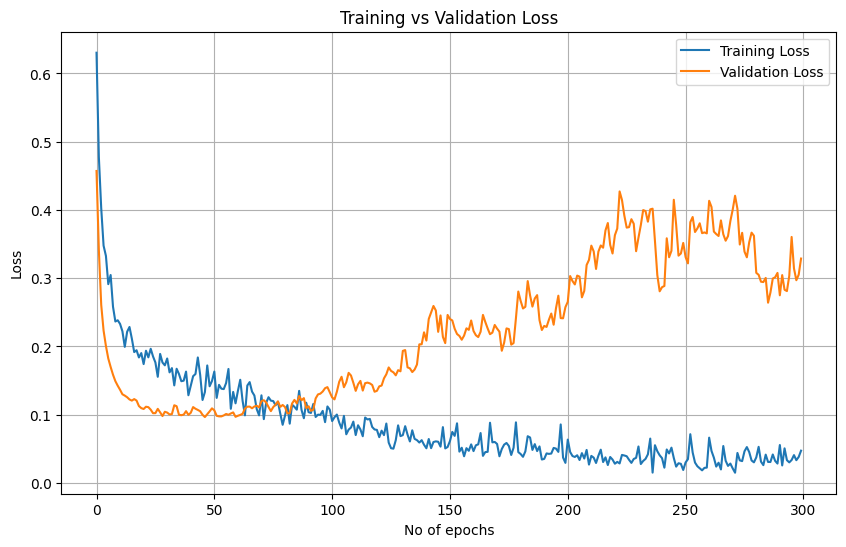

In [428]:
plt.figure(figsize=(10,6))
#### plot the training loss
plt.plot(history.history['loss'], label = 'Training Loss')
#### plot the validation loss
plt.plot(history.history['val_loss'], label = 'Validation Loss')
#### get the title of the model
plt.title('Training vs Validation Loss')
#### get the x axis of the graph
plt.xlabel('No of epochs')
#### get the y axis of the graph
plt.ylabel('Loss')
#### get the legend of the graph
plt.legend()
#### get the grid of the graph
plt.grid()
#### display the graph
plt.show()

#### **OBSERVATIONS:**

1.  With the increase in the number of epochs, the training loss of the model reduces continuously.

2.  But the Validation loss increases and is higher than the training loss

#### **Step 13: Make the Predictions**

In [429]:
Y_pred = model.predict(X_test_scaled)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [430]:
Y_pred

array([[2.9617733e-01],
       [1.0000000e+00],
       [9.9237263e-03],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [4.4191498e-03],
       [1.0000000e+00],
       [9.5674103e-01],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [9.9304658e-01],
       [1.0000000e+00],
       [9.7201663e-01],
       [1.0000000e+00],
       [6.6088974e-01],
       [9.9941880e-01],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.0000000e+00],
       [9.9350595e-01],
       [1.0000000e+00],
       [1.0000000e+00],
       [9.9993247e-01],
       [1.0000000e+00],
       [8.8381642e-01],
       [1.0000000e+00],
       [9.9995875e-01],
       [1.0000000e+00],
       [1.0000000e+00],
       [5.5007923e-01],
       [1.0000000e+00],
       [1.0000000e+00],
       [1.000000

#### **OBSERVATIONS:**

1.  The output has been predicted for the input test data using the ann sequential model.

In [431]:
type(Y_test)

pandas.core.series.Series

In [432]:
type(Y_pred)

numpy.ndarray

In [433]:
#### Construct the new dataframe
df_new = pd.DataFrame({
    'Actual Results' : Y_test.values,
    'Predicted Results' : Y_pred.flatten()
})

In [434]:
df_new

,Actual Results,Predicted Results
0,1,0.296177
1,1,1.000000
2,0,0.009924
3,1,1.000000
4,1,1.000000
...,...,...
75,1,1.000000
76,1,1.000000
77,0,0.312785
78,0,0.000835


#### **Step 14: Check whether the student will get the admission or not**

In [435]:
#### Set the threshold value
threshold=0.75
df_new['Admission Status'] = np.where(df_new['Predicted Results']>threshold,'Admitted','Not Admitted')

In [436]:
df_new

,Actual Results,Predicted Results,Admission Status
0,1,0.296177,Not Admitted
1,1,1.000000,Admitted
2,0,0.009924,Not Admitted
3,1,1.000000,Admitted
4,1,1.000000,Admitted
...,...,...,...
75,1,1.000000,Admitted
76,1,1.000000,Admitted
77,0,0.312785,Not Admitted
78,0,0.000835,Not Admitted
